# SHAP Analysis

This notebook is to perform a SHAP analysis to explain the prediction of the nowcasting model

| Lead Time | Threshold |
|-----------|-----------|
| 1h        | 0.20      |
| 3h        | 0.15      |
| 6h        | 0.05      |


# Choose the lead time and the classification threshold

In [ ]:
lead_time = 6
threshold = 0.05

# Module import

In [97]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import tensorflow as tf                                                                 
from joblib import load                                                           
import shap                                                                             
from sklearn.model_selection import train_test_split         
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # '0'=all, '1'=info, '2'=warning, '3'=error

In [98]:
test = pd.read_csv("../../../../output/data/dakar/data-test-eps-dakar.csv")
train = pd.read_csv("../../../../output/data/dakar/data-train-eps-dakar.csv")
train, validation = train_test_split(train, test_size=0.2, random_state=12)

In [99]:
def choose_header(n, location, lead_time):
    """
    Generate header names for n closest storms.

    Returns:
        tuple of two lists:
            - input headers: year, month, day, hour, minute, lat1..n, lon1..n, wp1..n, size1..n, d1..n, mask1..n
            - target header: Cb_{location}_t{lead_time}
    """
    input_headers = ['year', 'month', 'day', 'hour', 'minute']
    
    for prefix in ['lat', 'lon', 'wp', 'size', 'd', 'mask']:
        input_headers.extend([f'{prefix}{i}' for i in range(1, n + 1)])
    
    target_header = [f'Cb_{location}_t{lead_time}']
    
    return input_headers, target_header

In [100]:
input_headers = ['year', 'month', 'day', 'hour', 'minute']    
for prefix in ['lat', 'lon', 'wp', 'size', 'd', 'mask']:
    input_headers.extend([f'{prefix}{i}' for i in range(1, 4)])

In [101]:
X_test = test[input_headers]
y_test = test[f'Cb_dakar_t{lead_time}'].values.ravel()

In [102]:
X_train = train[input_headers]

In [103]:
for col in ['size1', 'size2', 'size3', 'wp1', 'wp2', 'wp3', 'd1', 'd2', 'd3']:
    X_test.loc[:, col] = np.log1p(X_test[col])
    X_train.loc[:, col] = np.log1p(X_train[col])

# Scaling

In [104]:
# Exclude mask columns from scaling
mask_cols = ['mask1', 'mask2', 'mask3']

# Final list of features to scale
cols_to_scale = [col for col in X_test.columns 
                 if col not in mask_cols]

scaler = load('../../lead-time-t1/model-dakar-t1.pkl')

X_train_scaled = X_train.copy()
X_train_scaled[cols_to_scale] = scaler.transform(X_train[cols_to_scale])

X_test_scaled = X_test.copy()
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Apply some filters here

In [105]:
real_mask_test = ((X_test['mask1'] == 1) & (X_test['mask2'] == 1) & (X_test['mask3'] == 1))
real_mask_train = ((X_train['mask1'] == 1) & (X_train['mask2'] == 1) & (X_train['mask3'] == 1))

In [106]:
X_test_scaled = X_test_scaled[real_mask_test]
X_train_scaled = X_train_scaled[real_mask_train]

In [107]:
background = X_train_scaled.sample(1000, random_state=42)

In [108]:
X_explain = X_test_scaled.sample(5000, random_state=1)
X_display = X_test.loc[X_explain.index]

# Loading models

In [109]:
model = tf.keras.models.load_model(f'../../lead-time-t{lead_time}/model-dakar-t{lead_time}.keras')

# Inference

In [110]:
explainer = shap.DeepExplainer(model, background.values)
y_pred = model.predict(X_explain).flatten()
pos_idx = y_pred > threshold
X_explain = X_explain[pos_idx]

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 740us/step


In [111]:
shap_values = explainer.shap_values(X_explain.values)
shap_values = shap_values[:, :, 0]

# Waterfall plot

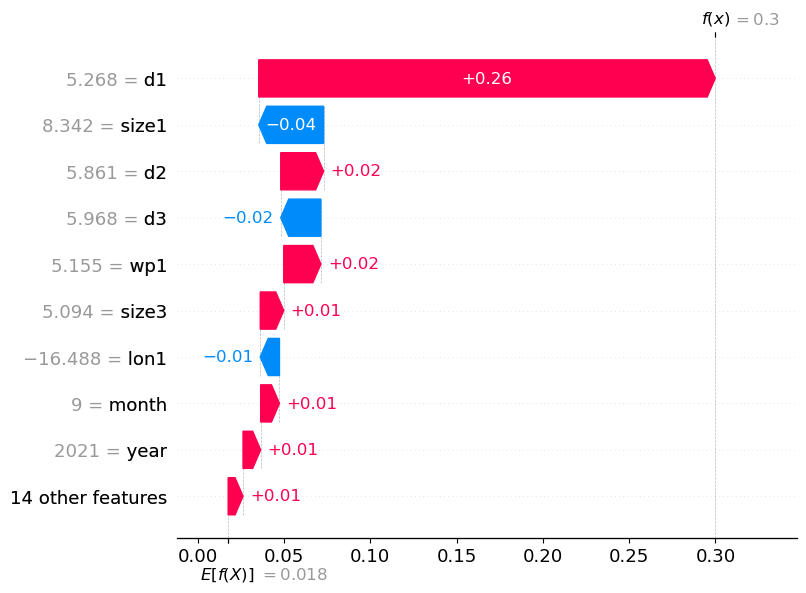

In [112]:
sample_index = 10

exp = shap.Explanation(
    values=shap_values[sample_index],
    base_values=float(explainer.expected_value[0]),
    data=X_display.iloc[sample_index].values,
    feature_names=X_display.columns
)

shap.plots.waterfall(exp, max_display=10)

# Summary plot

In [113]:
max_display = 10

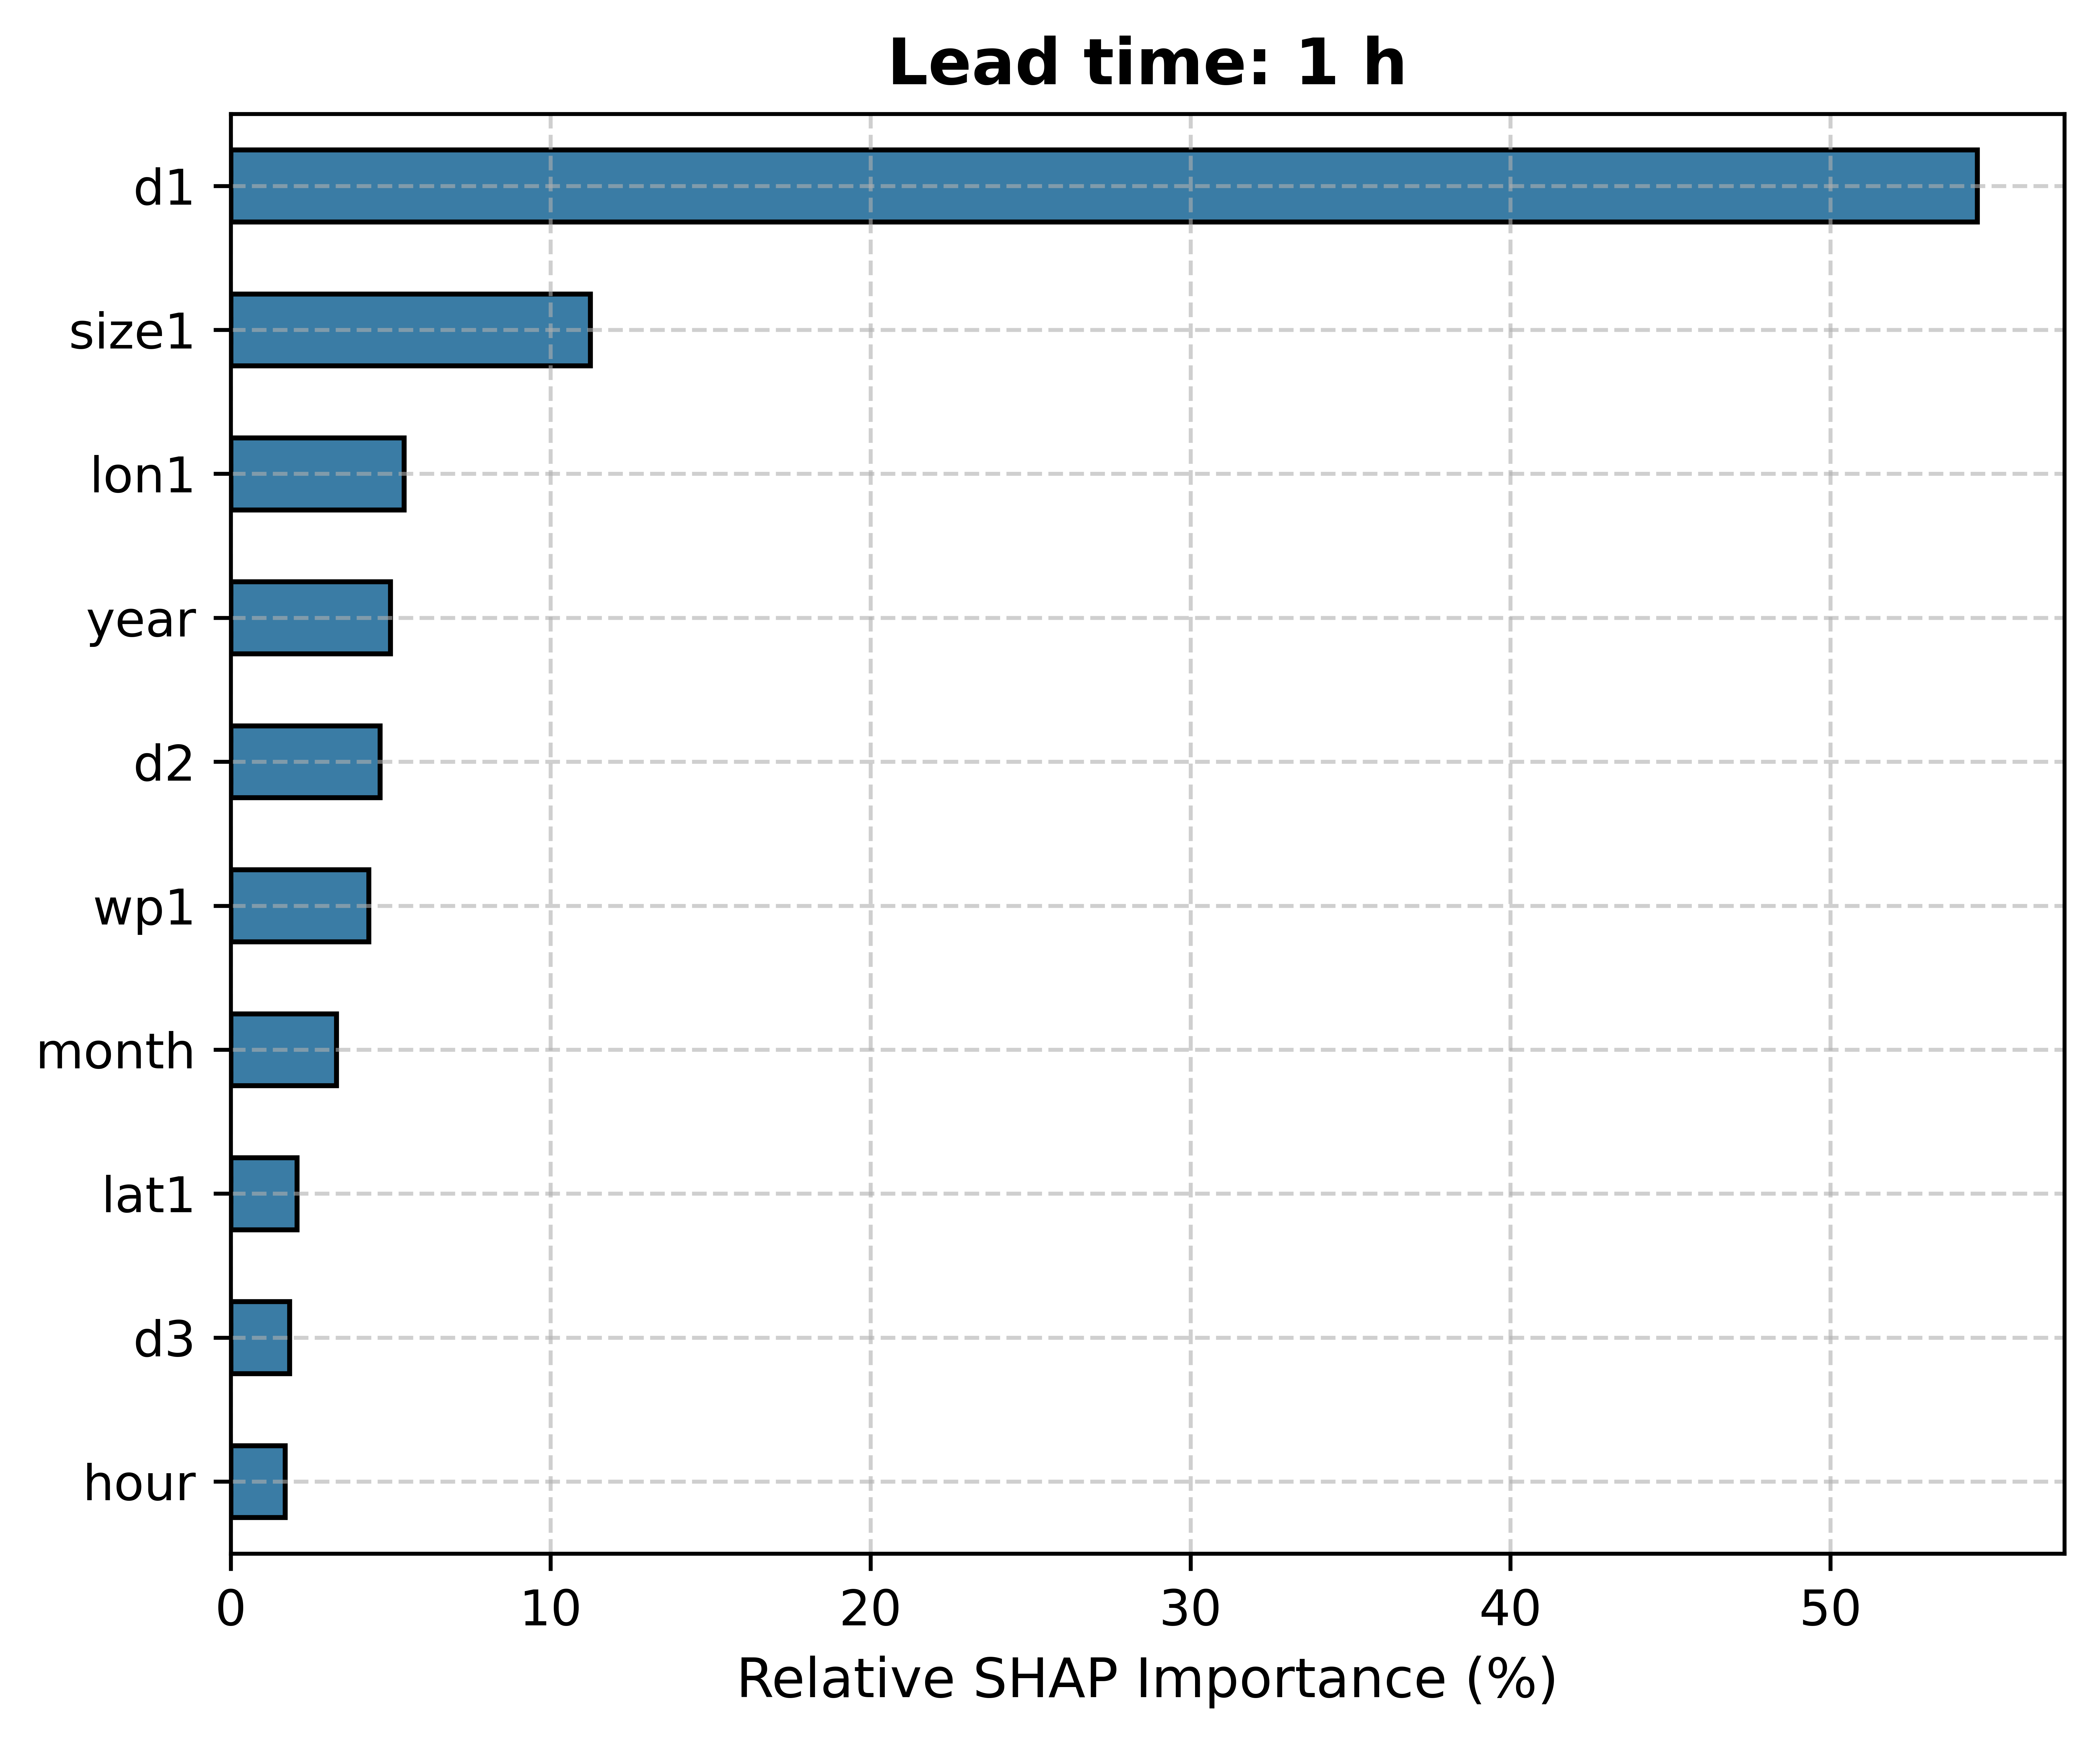

In [114]:
# Compute relative importance
mean_abs = np.abs(shap_values).mean(axis=0)
rel_importance = 100 * mean_abs / mean_abs.sum()
rel_series = pd.Series(rel_importance, index=X_explain.columns).sort_values(ascending=True)

# Plot high-res figure
fig, ax = plt.subplots(figsize=(6, 5), dpi=1200)
rel_series.tail(max_display).plot(kind="barh", ax=ax, color="#3A7CA5", edgecolor="black")

# Labels and styling
ax.set_xlabel("Relative SHAP Importance (%)", fontsize=11)
ax.set_title(f"Lead time: {lead_time} h", fontsize=13, weight='bold')
ax.tick_params(axis='both', labelsize=10)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save and show
plt.show()


# Cumulative SHAP contribution plot

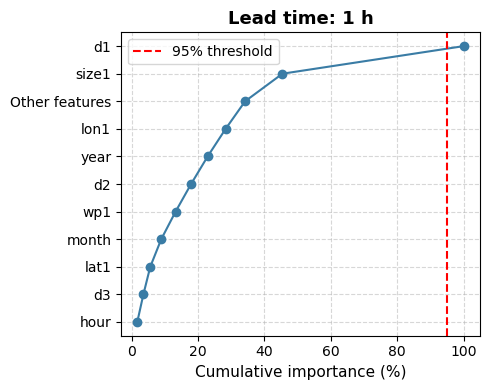

In [115]:
# Sort in descending order
sorted_rel_series = rel_series.sort_values(ascending=False)

# Select top 10 and sum the rest
top_10 = sorted_rel_series.head(10)
other_sum = sorted_rel_series.iloc[10:].sum()

# Combine into one series
final_series = pd.concat([top_10, pd.Series({"Other features": other_sum})])

# Calculate cumulative sum (ascending order for cumulative plot)
cumsum = final_series.sort_values(ascending=True).cumsum()

# Plot horizontally
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(cumsum.values, cumsum.index, marker='o', color="#3A7CA5")

# 95% threshold line
ax.axvline(95, color='red', linestyle='--', label="95% threshold")

ax.set_xlabel("Cumulative importance (%)", fontsize=11)
ax.set_title(f"Lead time: {lead_time} h", fontsize=13, weight='bold')

ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()


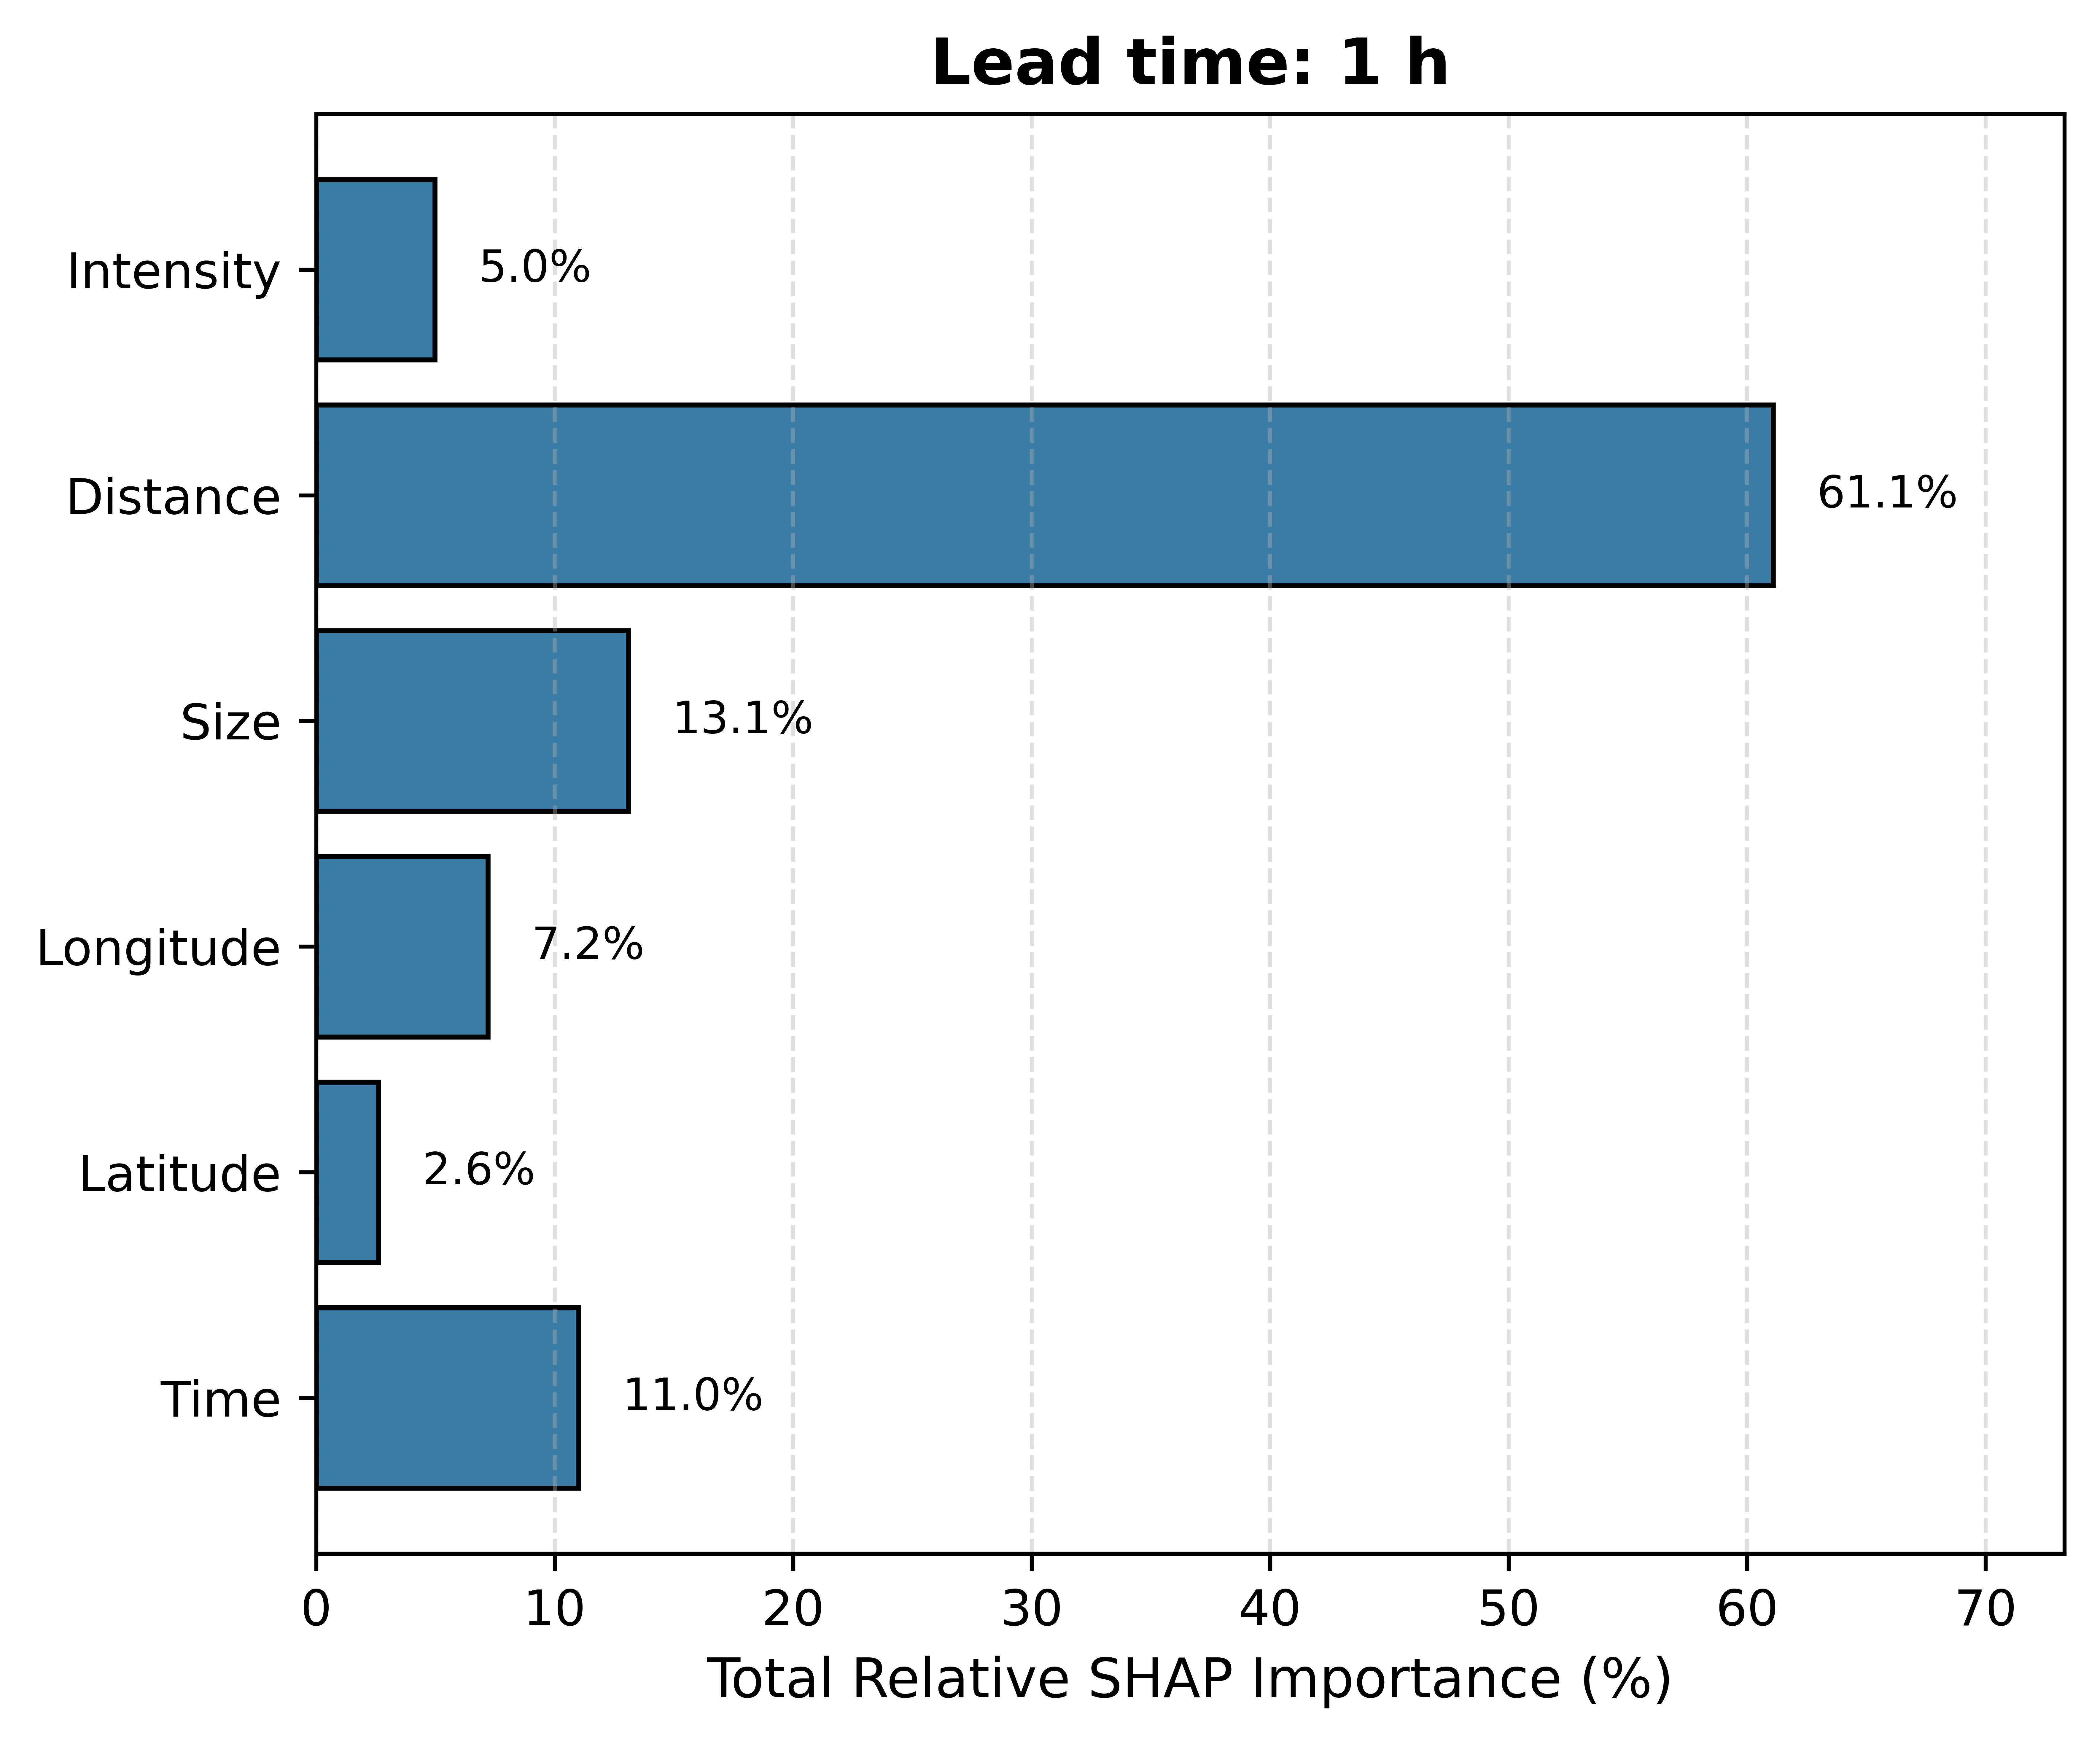

In [116]:
import matplotlib.pyplot as plt
import pandas as pd

# Define groups in fixed order
group_order = ["Time", "Latitude", "Longitude", "Size", "Distance", "Intensity"]
group_map = {
    "Time":     ["year", "month", "day", "hour", "minute"],
    "Latitude": [f"lat{i}" for i in range(1, 4)],
    "Longitude": [f"lon{i}" for i in range(1, 4)],
    "Size":     [f"size{i}" for i in range(1, 4)],
    "Distance": [f"d{i}" for i in range(1, 4)],
    "Intensity": [f"wp{i}" for i in range(1, 4)],
}

# Compute group importance
group_importance = {
    group: rel_series[rel_series.index.intersection(features)].sum()
    for group, features in group_map.items()
}

# Convert to Series with fixed order
group_series = pd.Series({k: group_importance[k] for k in group_order})

# Create high-res figure
fig, ax = plt.subplots(figsize=(6, 5), dpi=1200)
bars = ax.barh(group_series.index, group_series.values, color="#3A7CA5", edgecolor="black")

# Dynamic x-limit
max_width = group_series.values.max()
ax.set_xlim(0, max_width * 1.2)

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + max_width * 0.03, bar.get_y() + bar.get_height() / 2,
            f"{width:.1f}%", va='center', fontsize=9, color='black')

# Styling
ax.set_xlabel("Total Relative SHAP Importance (%)", fontsize=11)
ax.set_title(f"Lead time: {lead_time} h", fontsize=13, weight='bold')
ax.tick_params(axis='both', labelsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()

# Save and show
plt.savefig(f"shap_importance_leadtime_{lead_time}h.png", dpi=300, bbox_inches='tight')
plt.show()



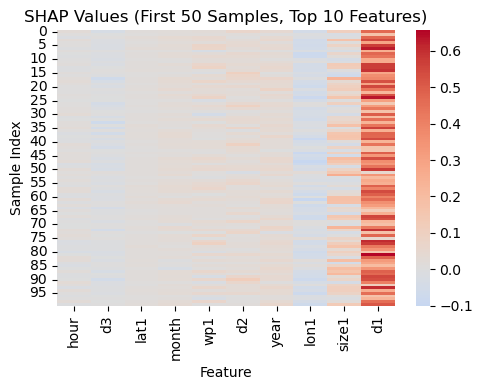

In [117]:
import seaborn as sns

top_features = rel_series.tail(10).index.tolist()
shap_df = pd.DataFrame(shap_values, columns=X_explain.columns)

plt.figure(figsize=(5, 4))
sns.heatmap(shap_df[top_features].iloc[:100], cmap="coolwarm", center=0)
plt.title("SHAP Values (First 50 Samples, Top 10 Features)")
plt.xlabel("Feature")
plt.ylabel("Sample Index")
plt.tight_layout()
plt.show()


# Summary plot

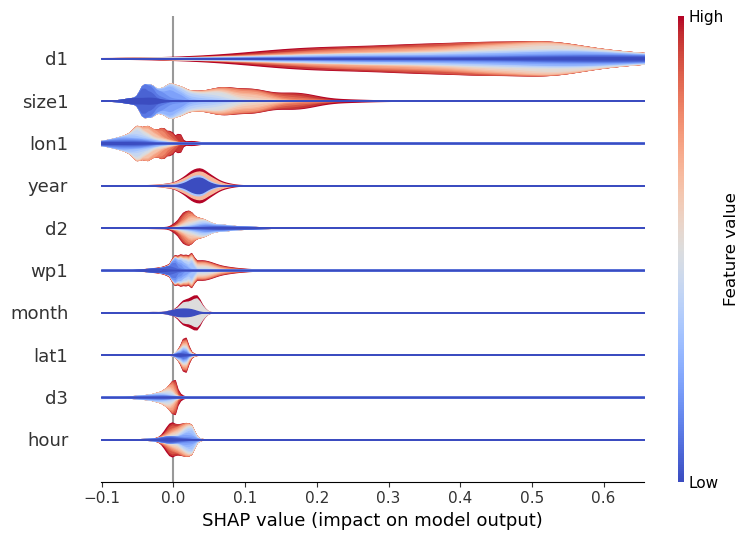

In [118]:
shap.summary_plot(shap_values, X_explain, plot_type="layered_violin", max_display=10, show=False)

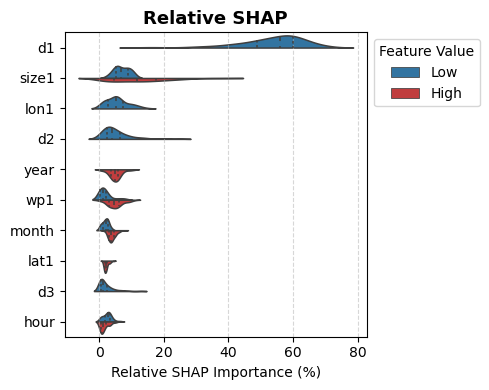

In [119]:
# Compute relative SHAP values per sample
abs_shap = np.abs(shap_values)
rel_shap = (abs_shap / abs_shap.sum(axis=1, keepdims=True)) * 100

# Create DataFrame
rel_shap_df = pd.DataFrame(rel_shap, columns=X_explain.columns)

# Select top 10 features by mean relative SHAP
top_features = rel_shap_df.mean().sort_values(ascending=False).head(10).index
top_rel_shap_df = rel_shap_df[top_features]

# Get corresponding feature values
feature_vals_df = X_explain[top_features].copy()

# Melt both SHAP and feature values
melted_shap = top_rel_shap_df.melt(var_name="Feature", value_name="Relative SHAP (%)")
melted_vals = feature_vals_df.melt(var_name="Feature", value_name="Feature Value")

# Combine SHAP and feature values into one dataframe
combined_df = melted_shap.copy()
combined_df["Feature Value"] = melted_vals["Feature Value"]

# Create low/high category for feature values
combined_df['Value Level'] = pd.qcut(combined_df["Feature Value"], 2, labels=["Low", "High"])

# Plot
plt.figure(figsize=(5, 4))
sns.violinplot(x="Relative SHAP (%)", 
               y="Feature", 
               hue="Value Level",
               data=combined_df, 
               split=True, 
               palette=["#1f77b4", "#d62728"],
               linewidth=1.1,
               inner='quartile')

plt.title("Relative SHAP", fontsize=13, weight='bold')
plt.xlabel("Relative SHAP Importance (%)")
plt.ylabel("")

plt.grid(True, linestyle='--', alpha=0.5, axis='x')
plt.legend(title="Feature Value", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()
